## 7.1 梯度优化方法 - Momentum

#### 1. 为什么需要 Momentum
在普通梯度下降中，参数更新公式为：

![Pasted Graphic 11.png](<attachment:Pasted Graphic 11.png>)

其中：

![Pasted Graphic 12.png](<attachment:Pasted Graphic 12.png>)

但是在神经网络训练中，普通梯度下降会出现一些问题：
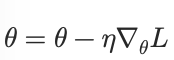
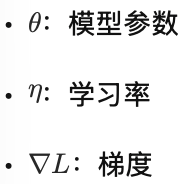

##### 1.1 平坦区域（Plateau）
在一些区域中，损失函数的曲面非常平缓：

在这种情况下：
* 梯度非常小

导致：
* 参数更新非常慢
* 训练可能会 长时间停留在平坦区域。

##### 1.2 鞍点（Saddle Point）
在高维空间中，鞍点非常常见。

特点：
* 梯度 = 0
* 但不是最小值

因此：
* 梯度下降可能停在鞍点附近
* 训练会 卡住。

##### 1.3 梯度震荡（Oscillation）
在一些损失函数中，曲面可能非常狭长

如果使用普通梯度下降：
* 参数更新会在两侧来回震荡

表现为：
* ↘ ↗ ↘ ↗ ↘ ↗

导致：
* 收敛速度很慢

##### 1.4 局部极小值（Local Minimum）
损失函数可能有很多局部最低点：

梯度下降可能会：
* 陷入局部最优
* 而不是找到 全局最优。

#### 2. Momentum 的核心思想
Momentum 的核心思想来自 **物理中的动量（Momentum）**。

在物理中：
* 物体在运动时会具有惯性

即：
* 当前速度
* 不仅取决于当前力
* 还取决于过去速度

Momentum 在优化中的思想是：
* 参数更新方向
* 不仅取决于当前梯度
* 还取决于过去梯度

#### 3. Momentum 的数学公式
公式与 **指数移动平均** 一致

##### 3.1 第一步：更新动量

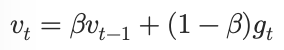

其中：

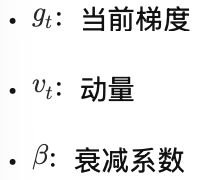

##### 3.2 第二步：更新参数

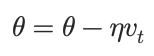

也就是说：
* 用平滑后的梯度更新参数
* 而不是直接使用当前梯度。

##### 3.3 ⚠️注意：
```
这里的每一次的梯度表示同一层的各个参数的梯度在每一个次 batch 训练之后的梯度
而不是表示同一个 batch 中的每一层的各个参数的梯度
```
1. 每一个 batch 会计算一次梯度
2. 这个梯度包含 所有参数的梯度
3. Momentum 会 对每一个参数的梯度序列做 EMA

这里的：

`g_t`

其实是：

`当前 batch 的梯度`

所以：
```
g1 = 第1个batch得到的梯度
g2 = 第2个batch得到的梯度
g3 = 第3个batch得到的梯度
```

#### 4. Momentum 的典型参数
常见设置：
```
β = 0.9
learning rate = 0.001 ~ 0.01
```
含义：
```
当前梯度权重 = 0.1
历史梯度权重 = 0.9
```
因此：
* Momentum 会记住过去的梯度趋势


#### 5. Momentum 在神经网络中的应用
假设梯度序列为：

这只是一个 简化示例。

真实神经网络中：每一层的梯度不是一个数。

而是：矩阵 / 向量

```
g1 = 5
g2 = -3
g3 = 6
g4 = -2
```

如果直接使用梯度：

`5 → -3 → 6 → -2`

更新方向会不断改变：

`→ ← → ←`

产生严重震荡。

**使用 Momentum（EMA）后：**
```
v1 = 0.5
v2 = 0.15
v3 = 0.735
v4 = 0.4615
```
得到：

`0.5 → 0.15 → 0.735 → 0.4615`

可以看到：
* 梯度变化更加平滑

因此：
* 更新方向更加稳定

##### 神经网络中的真实情况
假设：

`W1 是 100×50 矩阵`

那么 Momentum 会维护：

`v_W1 (100×50)`

更新公式：

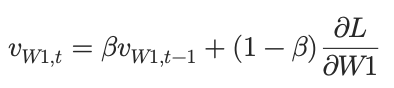

然后更新参数：

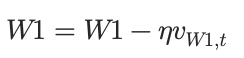

￼
同样：
```
W2 也有自己的 v_W2
b1 也有自己的 v_b1
b2 也有自己的 v_b2
```
所以实际上：
* 每个参数都有自己的 Momentum

#### 6. Momentum 如何加速收敛
Momentum 有两个重要效果：

##### 6.1 减少震荡
在狭长谷底：
* 梯度会左右震荡

Momentum 会：
* 平均这些震荡梯度
* 使得更新方向更稳定。

##### 6.2 加速正确方向的移动
如果梯度长期朝同一个方向：
```
g1 > 0
g2 > 0
g3 > 0
```

Momentum 会不断累积：
```
v1
v2
v3
```
相当于：
* 越来越大的更新速度

因此：
* 收敛更快

#### 7. Momentum 的物理类比
`可以把参数更新想象成一个球在山坡上滚动：`

普通梯度下降：
* 每一步重新开始

Momentum：
* 球具有惯性

如果方向一致：
* 速度越来越快

如果方向改变：
* 惯性会抑制震荡

#### 8. Momentum在Pytorch中的实现
在 Pytorch 中，Momentum 通常是通过 `SGD 优化器的 momentum 参数` 来实现的。

在 PyTorch / TensorFlow 中，`SGD` 指的是 `基于梯度的更新规则`，而不是严格意义上的 `Stochastic Gradient Descent（单样本梯度下降）`。

深度学习框架中：

`梯度下降类优化器`

它的含义更接近：

`Gradient Descent Optimizer`

只不过历史上大家习惯称为 `SGD`。

这个优化器 既可以用于 `mini-batch`，也可以用于 `full-batch`。

真正决定 batch 的不是`optimizer`，而是`DataLoader`

`dataloader = DataLoader(dataset, batch_size=32)`

##### 8.1 基本写法

In [1]:
import torch

# model 示例
model = torch.nn.Linear(1, 1)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

##### 8.2 参数说明
* model.parameters()
    * 表示把模型中所有可训练参数交给优化器管理
* lr=0.01
    * 学习率
* momentum=0.9
    * 动量系数，对应公式中的 beta

##### 8.3 说明：
* loss.backward()
    * 计算当前 batch 的所有参数梯度
* optimizer.step()
    * 内部会自动按照 Momentum 的规则更新参数

也就是说，我们虽然没有手动写 Momentum 公式￼

但 Pytorch 已经在 SGD(momentum=0.9) 内部帮我们实现了。